In [15]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 110

In [16]:
df_1_1 = pd.read_csv('query-results/QSection1-1.csv')
df_2_1 = pd.read_csv('query-results/QSection2-1.csv')
df_2_2 = pd.read_csv('query-results/QSection2-2.csv')

# 1 · Dataset Overview
Shape, dtypes, missing values, and descriptive statistics for **QSection1-1**, **QSection2-1**, and **QSection2-2**.

In [17]:
datasets = {
    'QSection1-1  (AI Publications per Year)': df_1_1,
    'QSection2-1  (Publications by Venue)':    df_2_1,
    'QSection2-2  (Publications by Topic/Year)': df_2_2,
}

for name, df in datasets.items():
    print(f'\n{"═"*65}')
    print(f'  {name}')
    print(f'{"═"*65}')
    print(f'  Shape          : {df.shape[0]} rows × {df.shape[1]} cols')
    print(f'  Columns        : {list(df.columns)}')
    print(f'  Dtypes         :')
    for col in df.columns:
        print(f'    {col:12s}  →  {df[col].dtype}')
    missing = df.isnull().sum()
    print(f'  Missing values : {missing.sum()} total  ({", ".join(f"{c}: {v}" for c, v in missing.items())})')
    print(f'  Duplicated rows: {df.duplicated().sum()}')
    print()
    display(df.describe(include="all").round(2))
    display(df.head())
    print()


═════════════════════════════════════════════════════════════════
  QSection1-1  (AI Publications per Year)
═════════════════════════════════════════════════════════════════
  Shape          : 52 rows × 2 cols
  Columns        : ['year', 'count']
  Dtypes         :
    year          →  int64
    count         →  int64
  Missing values : 0 total  (year: 0, count: 0)
  Duplicated rows: 0



,year,count
count,52.00,52.00
mean,1999.21,3136.58
std,15.65,4277.08
min,1969.00,64.00
25%,1986.75,460.00
50%,1999.50,1252.00
75%,2012.25,3520.00
max,2025.00,16867.00


,year,count
0,1969,64
1,1971,67
2,1973,86
3,1975,149
4,1977,236




═════════════════════════════════════════════════════════════════
  QSection2-1  (Publications by Venue)
═════════════════════════════════════════════════════════════════
  Shape          : 13 rows × 2 cols
  Columns        : ['topic', 'count']
  Dtypes         :
    topic         →  object
    count         →  int64
  Missing values : 0 total  (topic: 0, count: 0)
  Duplicated rows: 0



,topic,count
count,13,13.00
unique,13,NaN
top,2. Computer Vision (CVPR),NaN
freq,1,NaN
mean,NaN,15146.31
std,NaN,8815.68
min,NaN,1595.00
25%,NaN,11804.00
50%,NaN,15709.00
75%,NaN,17697.00


,topic,count
0,2. Computer Vision (CVPR),31677
1,4. General AI (AAAI),25882
2,1. Machine Learning (NeurIPS),25179
3,3. NLP & GenAI (ACL),17697
4,1. Machine Learning (ICML),17048




═════════════════════════════════════════════════════════════════
  QSection2-2  (Publications by Topic/Year)
═════════════════════════════════════════════════════════════════
  Shape          : 64 rows × 3 cols
  Columns        : ['year', 'topic', 'count']
  Dtypes         :
    year          →  int64
    topic         →  object
    count         →  int64
  Missing values : 0 total  (year: 0, topic: 0, count: 0)
  Duplicated rows: 0



,year,topic,count
count,64.00,64,64.00
unique,NaN,4,NaN
top,NaN,1. Machine Learning,NaN
freq,NaN,16,NaN
mean,2017.50,NaN,1764.70
std,4.65,NaN,1644.02
min,2010.00,NaN,77.00
25%,2013.75,NaN,672.50
50%,2017.50,NaN,998.00
75%,2021.25,NaN,2555.00


,year,topic,count
0,2010,1. Machine Learning,475
1,2010,2. Computer Vision,694
2,2010,3. NLP,393
3,2010,4. Knowledge Rep,95
4,2011,1. Machine Learning,474


---
# 2 · QSection1-1 — AI Publications Over Time
Year-by-year publication counts from **1969 – 2025**.

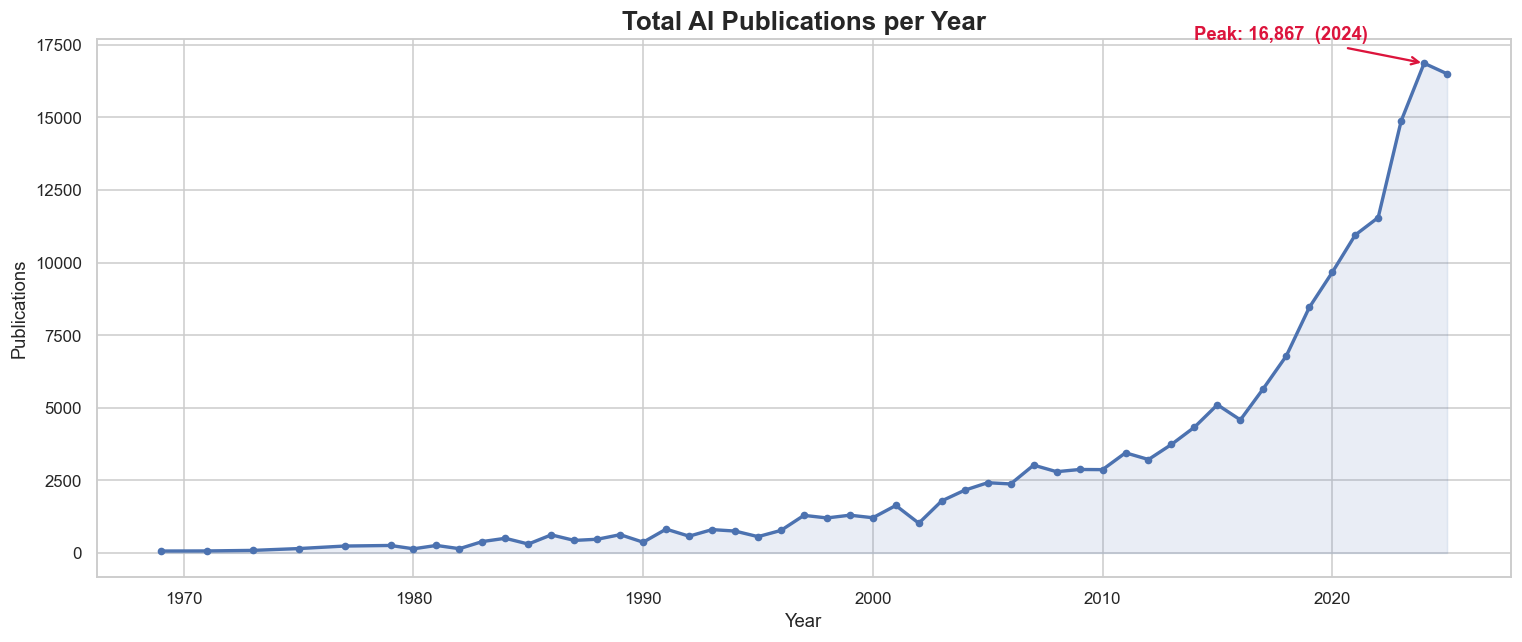

  Total publications : 163,102
  Year range         : 1969 – 2025
  Peak year          : 2024 (16,867 papers)
  Median annual count: 1,252


In [18]:
df1 = df_1_1.sort_values('year').copy()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df1['year'], df1['count'], marker='o', ms=4, lw=2.2, color='#4C72B0')
ax.fill_between(df1['year'], df1['count'], alpha=0.12, color='#4C72B0')

# annotate peak
peak = df1.loc[df1['count'].idxmax()]
ax.annotate(f"Peak: {peak['count']:,}  ({int(peak['year'])})",
            xy=(peak['year'], peak['count']),
            xytext=(peak['year']-10, peak['count']+800),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5),
            fontsize=12, color='crimson', fontweight='bold')

ax.set_title('Total AI Publications per Year', fontsize=17, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Publications')
plt.tight_layout(); plt.show()

print(f"  Total publications : {df1['count'].sum():,}")
print(f"  Year range         : {df1['year'].min()} – {df1['year'].max()}")
print(f"  Peak year          : {int(peak['year'])} ({peak['count']:,} papers)")
print(f"  Median annual count: {df1['count'].median():,.0f}")

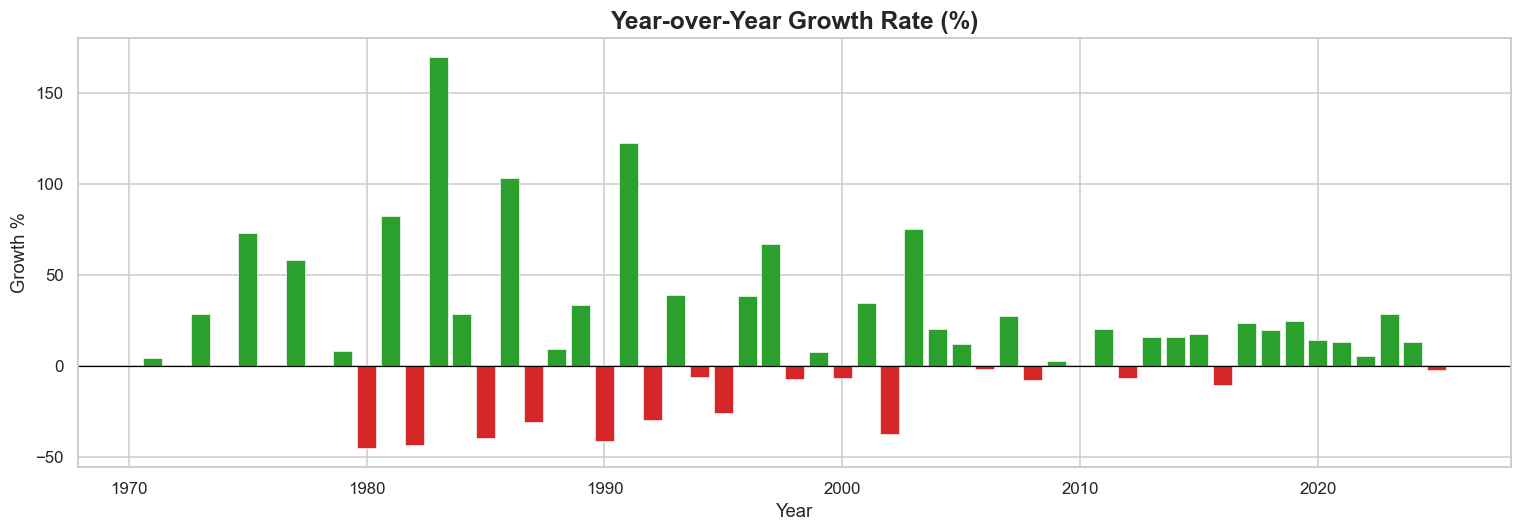

  Years with positive growth : 34
  Years with negative growth : 17
  Mean positive growth       : 37.1%
  Mean negative growth       : -20.1%
  Largest single-year jump   : 1983  (+169.7%)


In [19]:
df1['yoy_pct'] = df1['count'].pct_change() * 100

fig, ax = plt.subplots(figsize=(14, 5))
clrs = ['#2ca02c' if v >= 0 else '#d62728' for v in df1['yoy_pct'].fillna(0)]
ax.bar(df1['year'], df1['yoy_pct'], color=clrs, edgecolor='white', lw=0.4)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Year-over-Year Growth Rate (%)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Growth %')
plt.tight_layout(); plt.show()

pos = df1[df1['yoy_pct'] > 0]['yoy_pct']
neg = df1[df1['yoy_pct'] < 0]['yoy_pct']
print(f"  Years with positive growth : {len(pos)}")
print(f"  Years with negative growth : {len(neg)}")
print(f"  Mean positive growth       : {pos.mean():.1f}%")
print(f"  Mean negative growth       : {neg.mean():.1f}%")
print(f"  Largest single-year jump   : {df1.loc[df1['yoy_pct'].idxmax(), 'year']:.0f}  (+{df1['yoy_pct'].max():.1f}%)")

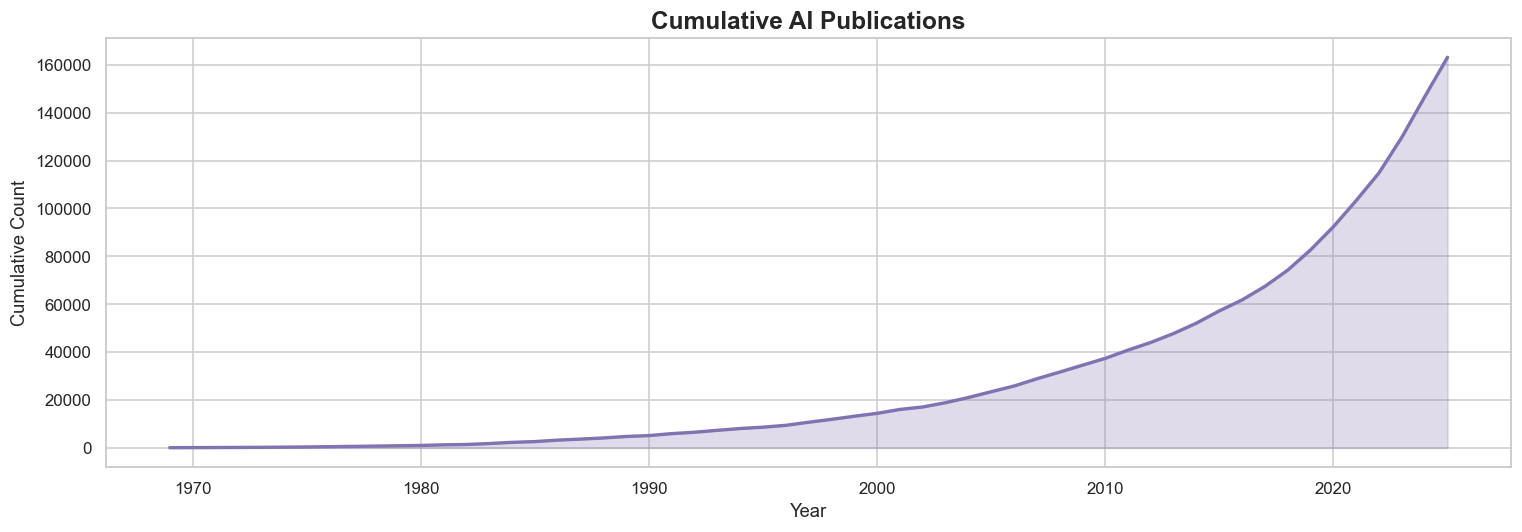

  50 % of all publications were produced after 2019


In [20]:
df1['cumulative'] = df1['count'].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df1['year'], df1['cumulative'], alpha=0.25, color='#8172B2')
ax.plot(df1['year'], df1['cumulative'], lw=2.2, color='#8172B2')
ax.set_title('Cumulative AI Publications', fontsize=16, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Cumulative Count')
plt.tight_layout(); plt.show()

# when did we cross 50 % of total output?
half = df1['cumulative'].iloc[-1] / 2
cross = df1.loc[df1['cumulative'] >= half, 'year'].iloc[0]
print(f"  50 % of all publications were produced after {int(cross)}")

---
# 3 · QSection2-1 — Publications by Venue
Total publication count for each major AI conference.

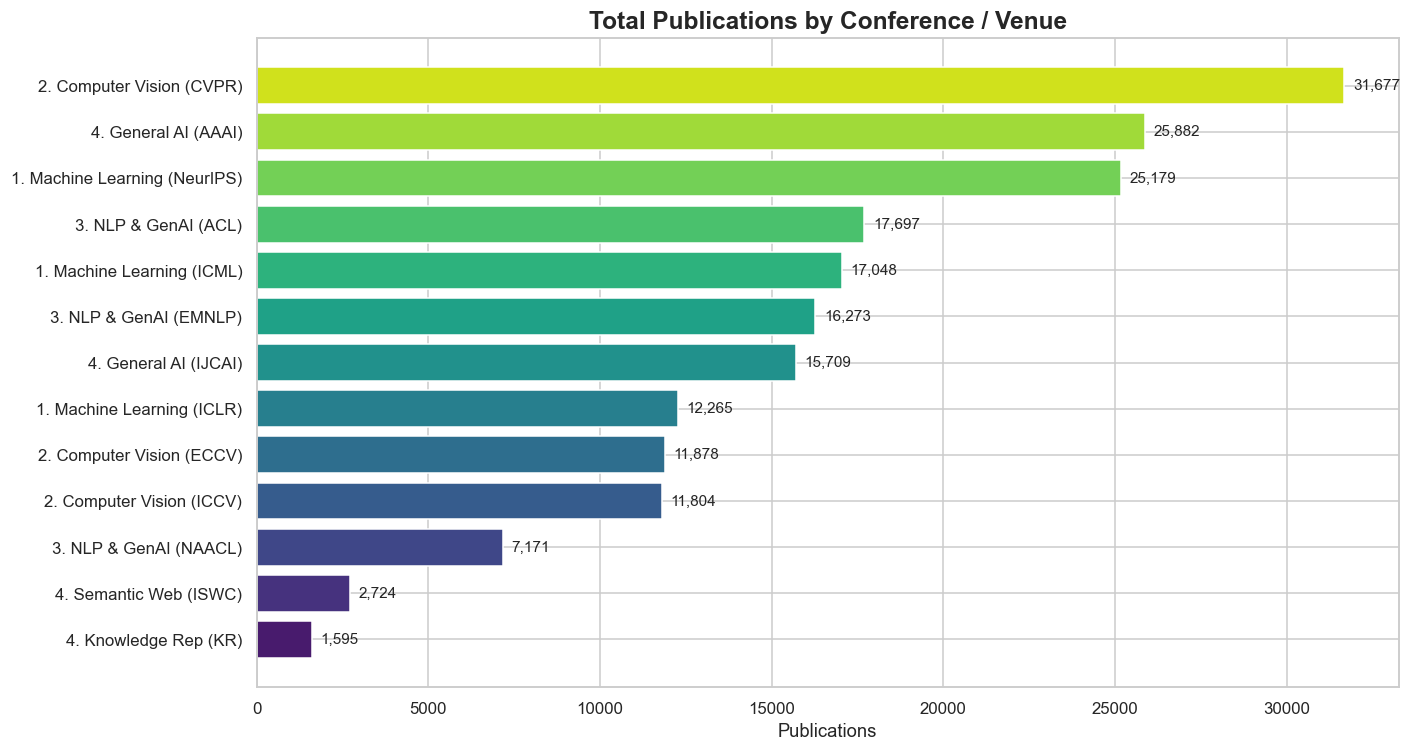

  Total across all venues : 196,902
  Number of venues        : 13
  Top venue               : 2. Computer Vision (CVPR)
  Bottom venue             : 4. Knowledge Rep (KR)
  Mean per venue           : 15,146
  Std dev                  : 8,816


In [21]:
df2 = df_2_1.sort_values('count', ascending=True).copy()

fig, ax = plt.subplots(figsize=(13, 7))
palette = sns.color_palette('viridis', len(df2))
bars = ax.barh(df2['topic'], df2['count'], color=palette, edgecolor='white')
for b in bars:
    w = b.get_width()
    ax.text(w + 250, b.get_y() + b.get_height()/2, f'{w:,.0f}', va='center', fontsize=10)
ax.set_title('Total Publications by Conference / Venue', fontsize=16, fontweight='bold')
ax.set_xlabel('Publications')
plt.tight_layout(); plt.show()

print(f"  Total across all venues : {df_2_1['count'].sum():,}")
print(f"  Number of venues        : {len(df_2_1)}")
print(f"  Top venue               : {df_2_1.loc[df_2_1['count'].idxmax(), 'topic']}")
print(f"  Bottom venue             : {df_2_1.loc[df_2_1['count'].idxmin(), 'topic']}")
print(f"  Mean per venue           : {df_2_1['count'].mean():,.0f}")
print(f"  Std dev                  : {df_2_1['count'].std():,.0f}")

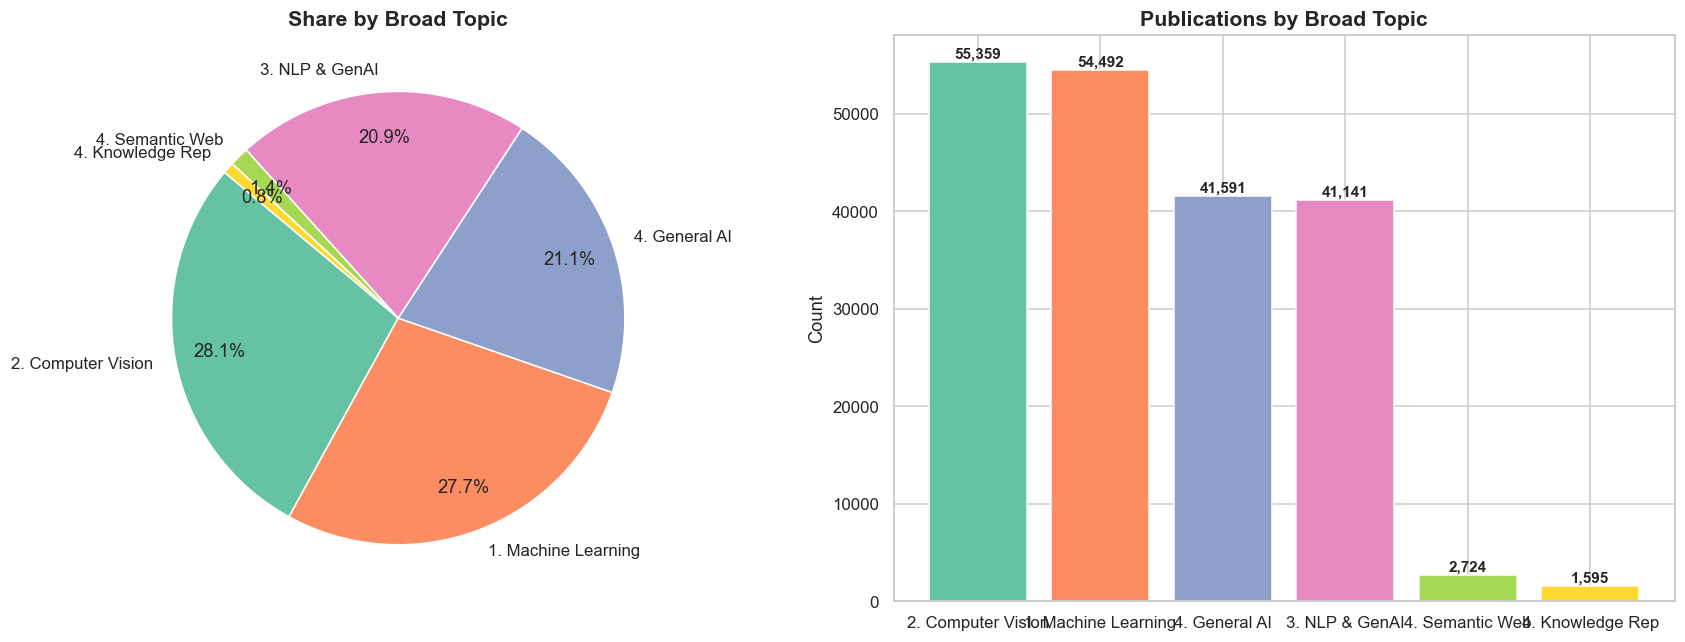

  Broad-topic breakdown:
    2. Computer Vision        →  55,359  (28.1%)
    1. Machine Learning       →  54,492  (27.7%)
    4. General AI             →  41,591  (21.1%)
    3. NLP & GenAI            →  41,141  (20.9%)
    4. Semantic Web           →   2,724  (1.4%)
    4. Knowledge Rep          →   1,595  (0.8%)


In [22]:
# extract broad topic from the prefix  e.g. "1. Machine Learning"
df_2_1['broad'] = df_2_1['topic'].str.extract(r'^(\d+\..+?)\s*\(')[0]
topic_agg = df_2_1.groupby('broad')['count'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = sns.color_palette('Set2', len(topic_agg))

# pie
axes[0].pie(topic_agg, labels=topic_agg.index, autopct='%1.1f%%',
            colors=colors, startangle=140, pctdistance=0.80)
axes[0].set_title('Share by Broad Topic', fontsize=14, fontweight='bold')

# bar
axes[1].bar(topic_agg.index, topic_agg.values, color=colors, edgecolor='white')
for i, v in enumerate(topic_agg.values):
    axes[1].text(i, v + 400, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Publications by Broad Topic', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout(); plt.show()

print('  Broad-topic breakdown:')
for t, c in topic_agg.items():
    print(f'    {t:25s} → {c:>7,}  ({c/topic_agg.sum()*100:.1f}%)')

---
# 4 · QSection2-2 — Topic Trends Over Time
Yearly publication counts for each AI research topic (2010–2025).

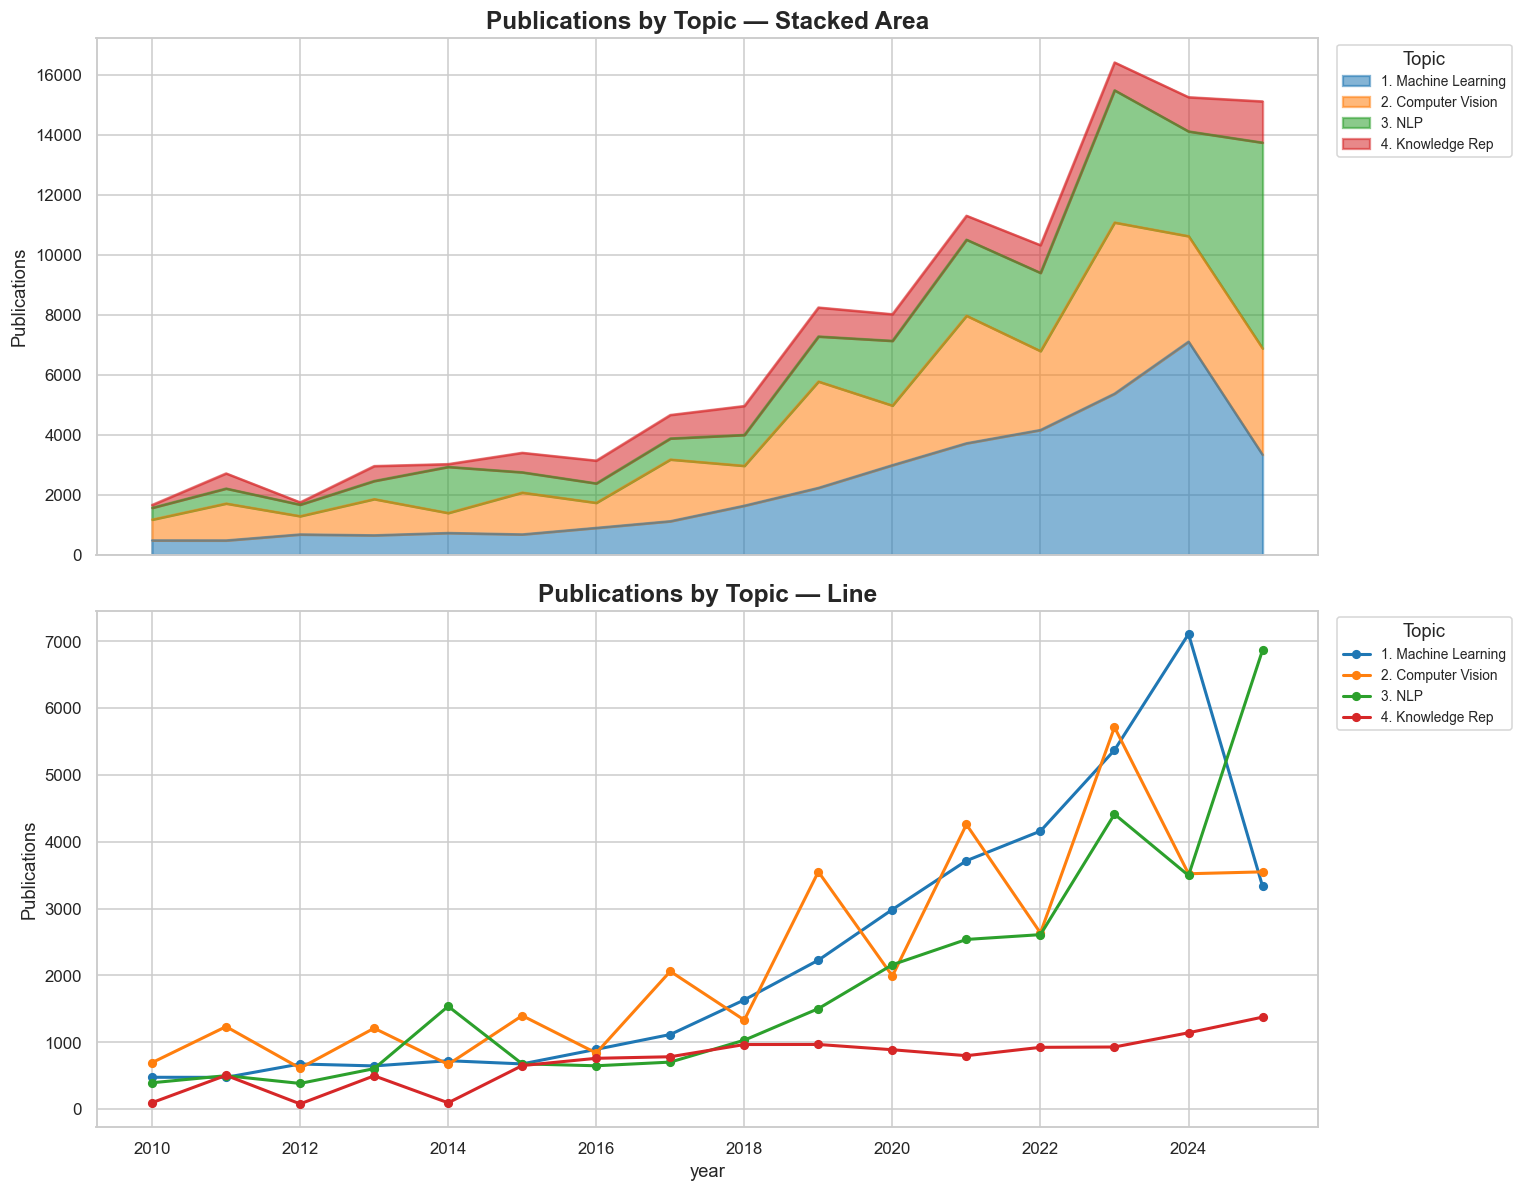

  Latest year totals (2025):
    1. Machine Learning    →  3,332
    2. Computer Vision     →  3,548
    3. NLP                 →  6,866
    4. Knowledge Rep       →  1,375


In [23]:
pivot = df_2_2.pivot_table(index='year', columns='topic', values='count', aggfunc='sum')
cpal = sns.color_palette('tab10', len(pivot.columns))

fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

pivot.plot.area(ax=axes[0], alpha=0.55, color=cpal, lw=1.5)
axes[0].set_title('Publications by Topic — Stacked Area', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Publications')
axes[0].legend(title='Topic', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

pivot.plot(ax=axes[1], marker='o', ms=5, lw=2, color=cpal)
axes[1].set_title('Publications by Topic — Line', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Publications')
axes[1].legend(title='Topic', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout(); plt.show()

print('  Latest year totals (2025):')
for col in pivot.columns:
    print(f'    {col:22s} → {pivot[col].iloc[-1]:>6,.0f}')

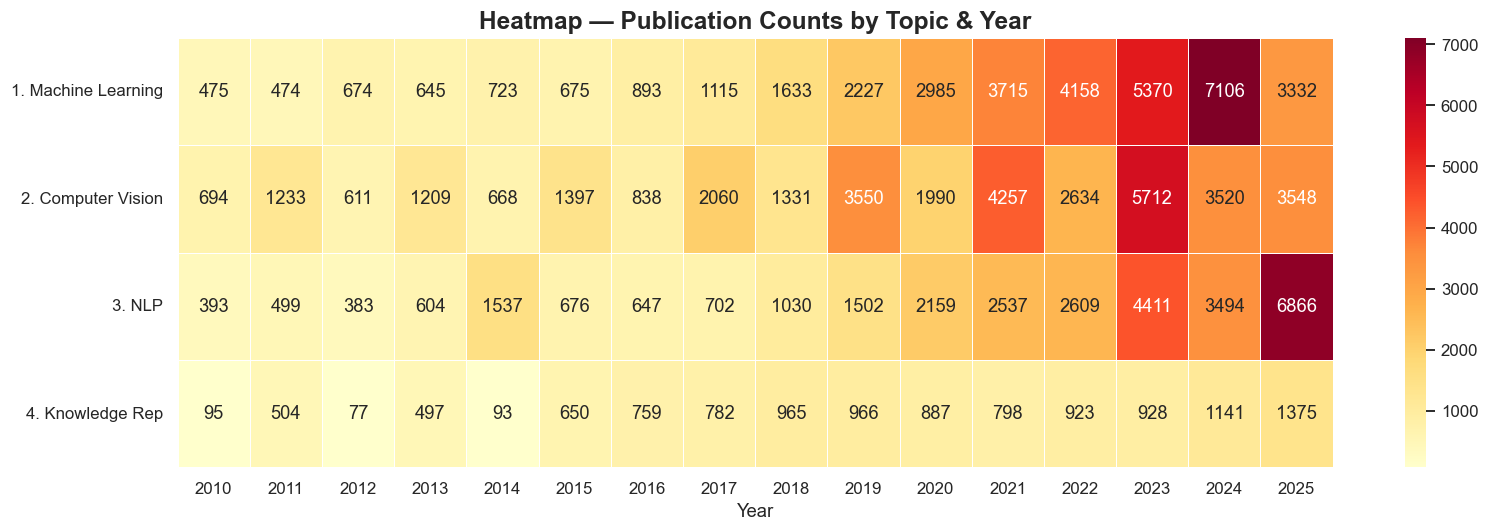

In [24]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(pivot.T, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=.5, ax=ax)
ax.set_title('Heatmap — Publication Counts by Topic & Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

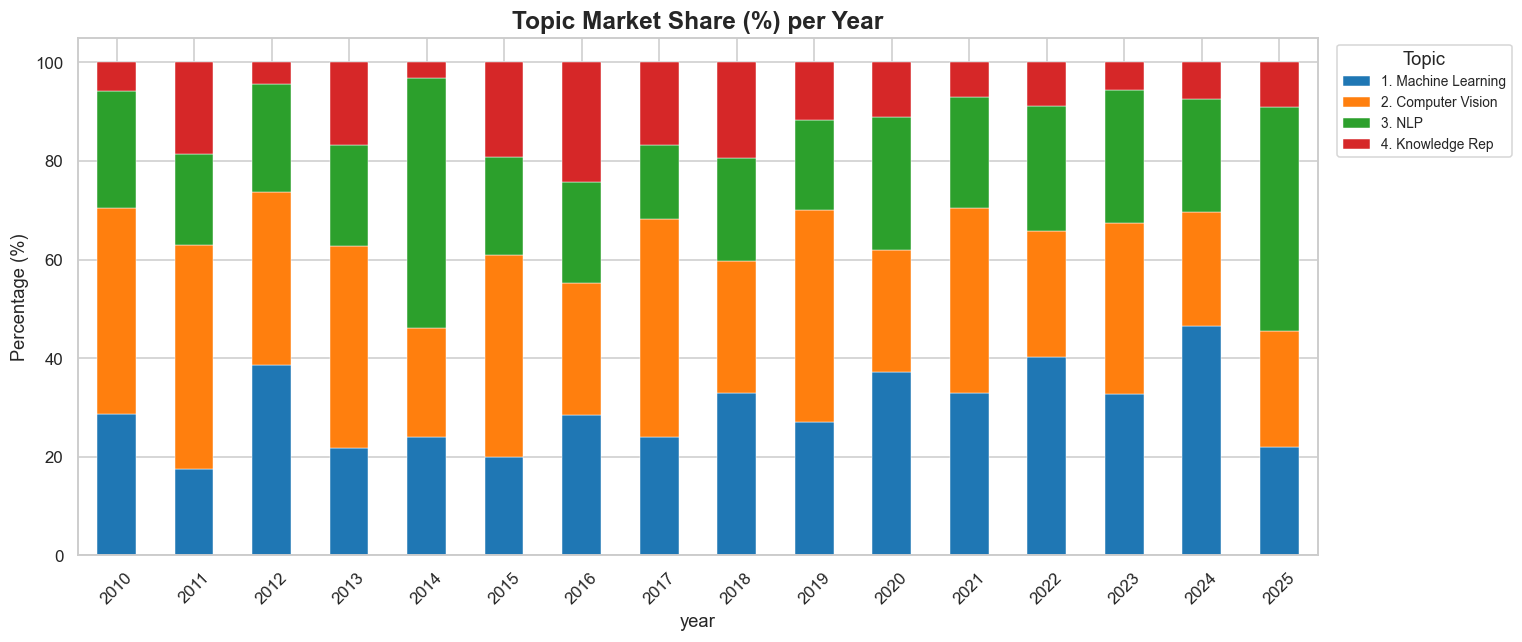

  Dominant topic per year:
    2010  →  2. Computer Vision (41.9%)
    2011  →  2. Computer Vision (45.5%)
    2012  →  1. Machine Learning (38.6%)
    2013  →  2. Computer Vision (40.9%)
    2014  →  3. NLP (50.9%)
    2015  →  2. Computer Vision (41.1%)
    2016  →  1. Machine Learning (28.5%)
    2017  →  2. Computer Vision (44.2%)
    2018  →  1. Machine Learning (32.9%)
    2019  →  2. Computer Vision (43.1%)
    2020  →  1. Machine Learning (37.2%)
    2021  →  2. Computer Vision (37.6%)
    2022  →  1. Machine Learning (40.3%)
    2023  →  2. Computer Vision (34.8%)
    2024  →  1. Machine Learning (46.6%)
    2025  →  3. NLP (45.4%)


In [25]:
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
pivot_pct.plot.bar(stacked=True, ax=ax, color=cpal, edgecolor='white', lw=.3)
ax.set_title('Topic Market Share (%) per Year', fontsize=16, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Topic', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_xticklabels([int(float(t.get_text())) for t in ax.get_xticklabels()], rotation=45)
plt.tight_layout(); plt.show()

print('  Dominant topic per year:')
for yr in pivot_pct.index:
    dom = pivot_pct.loc[yr].idxmax()
    print(f'    {yr}  →  {dom} ({pivot_pct.loc[yr, dom]:.1f}%)')

---
# 5 · Correlation & Summary
Inter-topic correlation and compound annual growth rates.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=1, ax=ax)
ax.set_title('Inter-Topic Correlation (2010–2025)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# ── CAGR ──
n = pivot.index[-1] - pivot.index[0]  # years
print('\n📈  Compound Annual Growth Rate (CAGR) 2010 → 2025')
print('─' * 52)
cagrs = {}
for col in pivot.columns:
    v0, v1 = pivot[col].iloc[0], pivot[col].iloc[-1]
    if v0 > 0:
        c = (v1 / v0) ** (1 / n) - 1
        cagrs[col] = c
        print(f'    {col:22s}  {c:>+7.1%}')

fastest = max(cagrs, key=cagrs.get)
slowest = min(cagrs, key=cagrs.get)
print(f'\n  ⮞ Fastest-growing topic : {fastest}  ({cagrs[fastest]:+.1%} CAGR)')
print(f'  ⮞ Slowest-growing topic : {slowest}  ({cagrs[slowest]:+.1%} CAGR)')

# ── Overall summary ──
print('\n' + '═'*55)
print('  📊  OVERALL SUMMARY')
print('═'*55)
print(f'  Total AI publications (1969–2025)    : {df_1_1["count"].sum():>10,}')
print(f'  Total across 13 venues (QSection2-1) : {df_2_1["count"].sum():>10,}')
print(f'  Publications in 2025 alone           : {df_1_1[df_1_1["year"]==2025]["count"].values[0]:>10,}')
print(f'  Number of venues analysed            : {len(df_2_1):>10}')
print(f'  Number of broad topics               : {len(topic_agg):>10}')
print(f'  Year span in QSection2-2             : {pivot.index.min()} – {pivot.index.max()}')
print(f'  Top venue by output                  : {df_2_1.loc[df_2_1["count"].idxmax(), "topic"]}')
print(f'  Dominant broad topic                 : {topic_agg.idxmax()}  ({topic_agg.max():,})')